# 01 — Baselines: Zero-Shot Prompting & T2L Zero-Shot

Two baselines against which fine-tuned LoRA will be compared:

| Stage | Method | Description |
|-------|--------|-------------|
| 0 | Zero-shot prompting | Mistral-7B-Instruct with a structured prompt, no adapter |
| 1 | T2L zero-shot | Hypernetwork generates a LoRA from the task description alone |

**GPU**: T4 (16 GB) is sufficient for both stages. Request it in Runtime → Change runtime type.

**Expected runtimes** (T4):
- Stage 0: ~15 min for full test set
- Stage 1: ~20 min (includes hypernetwork forward pass + LoRA application)

**HF token**: Mistral-7B-Instruct-v0.2 is gated. Before running cell 3, add `HF_TOKEN` via Colab Secrets (left sidebar → key icon) and accept the model license at huggingface.co/mistralai/Mistral-7B-Instruct-v0.2.

## Setup

In [1]:
# ── 0. Environment setup ───────────────────────────────────────────────────────
import sys, os

try:
    import google.colab
    IN_COLAB = True
    from google.colab import userdata
    print('Running on Google Colab')
except ImportError:
    IN_COLAB = False
    print('Running locally')

REPO_URL  = 'https://github.com/michaelarutyunov/text-to-lora-demo.git'
REPO_NAME = 'text-to-lora-demo'
T2L_REPO  = 'https://github.com/SakanaAI/text-to-lora.git'

if IN_COLAB:
    if not os.path.exists(f'/content/{REPO_NAME}'):
        !git clone {REPO_URL} /content/{REPO_NAME}
    else:
        !cd /content/{REPO_NAME} && git pull
    %cd /content/{REPO_NAME}

    if not os.path.exists('/content/text-to-lora'):
        !git clone {T2L_REPO} /content/text-to-lora
    if '/content/text-to-lora' not in sys.path:
        sys.path.insert(0, '/content/text-to-lora')

    !pip install -q -r requirements_colab.txt

    # HF token — needed for gated Mistral model. Gracefully absent here;
    # cell 3 will fail if not set before running it.
    try:
        HF_TOKEN = userdata.get('HF_TOKEN')
    except Exception:
        HF_TOKEN = None
        print('Note: HF_TOKEN not set - add via Colab Secrets before running cell 3.')
else:
    repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
    os.chdir(repo_root)
    from dotenv import load_dotenv; load_dotenv()
    HF_TOKEN = os.environ.get('HF_TOKEN')

if 'src' not in sys.path:
    sys.path.insert(0, 'src')

print(f'Working directory: {os.getcwd()}')
print(f'HF token present: {bool(HF_TOKEN)}')

Running on Google Colab
Already up to date.
/content/text-to-lora-demo
Note: HF_TOKEN not set - add via Colab Secrets before running cell 3.
Working directory: /content/text-to-lora-demo
HF token present: False


In [2]:
# ── 1. GPU check ───────────────────────────────────────────────────────────────
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

CUDA available: True
Device: Tesla T4
VRAM: 15.6 GB


In [3]:
# ── 2. Load test split ─────────────────────────────────────────────────────────
from data_utils import load_splits, NODE_TYPES, LABEL2ID, format_prompt, extract_label_from_response

splits = load_splits('data/processed')
test_examples = splits['test']
print(f'Test set: {len(test_examples)} examples')

# Cap at N for a quick smoke test; set to None for full eval
EVAL_LIMIT = None
if EVAL_LIMIT:
    import random
    random.seed(42)
    test_examples = random.sample(test_examples, EVAL_LIMIT)
    print(f'Capped to {EVAL_LIMIT} examples')

Test set: 197 examples


In [4]:
# ── 3. Load base model ────────────────────────────────────────────────────────
# Mistral-7B-Instruct-v0.2 — same base used by T2L
# Requires HF_TOKEN (gated model). Accept license at:
# huggingface.co/mistralai/Mistral-7B-Instruct-v0.2
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

BASE_MODEL = 'mistralai/Mistral-7B-Instruct-v0.2'

print(f'Loading tokenizer: {BASE_MODEL}')
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token

print('Loading model (bfloat16, auto device map)...')
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype=torch.bfloat16,
    device_map='auto',
    token=HF_TOKEN,
)
model.eval()
print('Model loaded.')

Loading tokenizer: mistralai/Mistral-7B-Instruct-v0.2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Model loaded.


In [5]:
# ── 4. Inference helper ────────────────────────────────────────────────────────
@torch.no_grad()
def predict_label(prompt: str, max_new_tokens: int = 12) -> str:
    """Greedy decode; extract first valid label from generation."""
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
    new_tokens = outputs[0][inputs['input_ids'].shape[1]:]
    raw = tokenizer.decode(new_tokens, skip_special_tokens=True)
    return extract_label_from_response(raw)

## Stage 0

In [6]:
# ── 5. Stage 0: Zero-shot prompting ───────────────────────────────────────────
from tqdm.auto import tqdm
from collections import Counter

print('Stage 0: zero-shot prompting (no adapter)...')

stage0_preds, stage0_labels = [], []
for ex in tqdm(test_examples, desc='Stage 0'):
    prompt = format_prompt(ex, include_answer=False)
    pred = predict_label(prompt)
    stage0_preds.append(pred)
    stage0_labels.append(ex['node_type'])

acc0 = sum(p == l for p, l in zip(stage0_preds, stage0_labels)) / len(stage0_labels)
print(f'\nStage 0 accuracy: {acc0:.3f}')
print(f'Unknown predictions: {Counter(stage0_preds)["unknown"]}')

Stage 0: zero-shot prompting (no adapter)...


Stage 0:   0%|          | 0/197 [00:00<?, ?it/s]


Stage 0 accuracy: 0.426
Unknown predictions: 23


Classification report (Stage 0 — 174/197 valid predictions):
                   precision    recall  f1-score   support

       pain_point       0.57      0.86      0.68        74
       gain_point       0.60      0.32      0.41        19
    emotional_job       0.29      0.30      0.29        20
solution_approach       0.57      0.17      0.27        23
    job_statement       0.00      0.00      0.00        16
      job_context       0.18      0.21      0.19        14
      job_trigger       0.33      0.14      0.20         7
       social_job       0.00      0.00      0.00         1

         accuracy                           0.48       174
        macro avg       0.32      0.25      0.26       174
     weighted avg       0.44      0.48      0.43       174



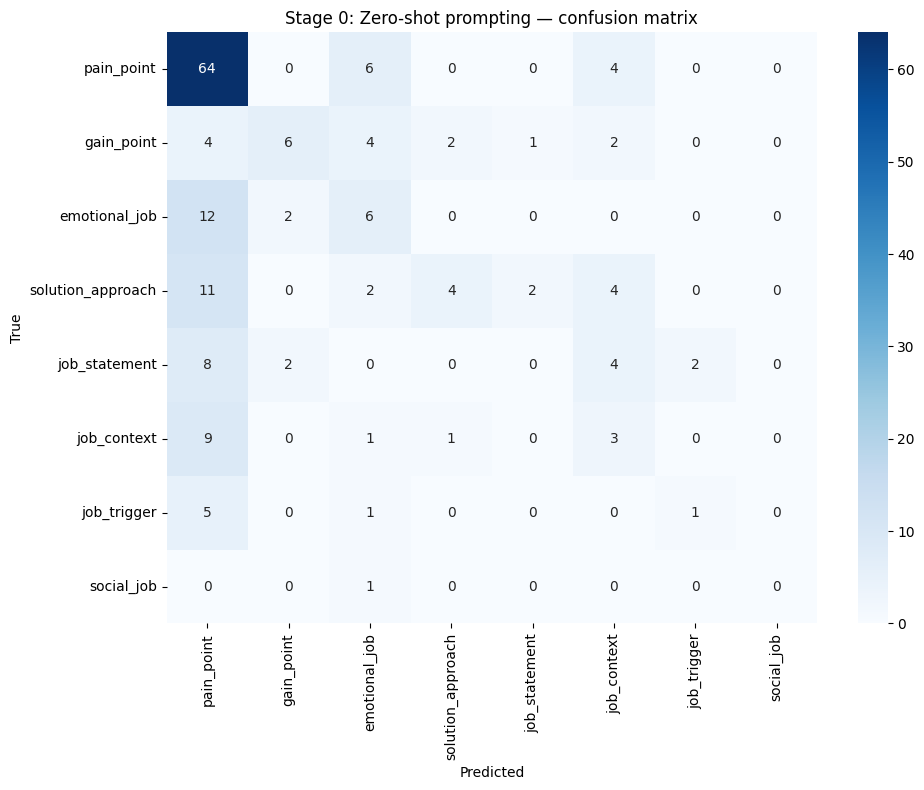

In [7]:
# ── 6. Stage 0 evaluation report ─────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

valid_mask = [p != 'unknown' for p in stage0_preds]
valid_preds = [p for p, m in zip(stage0_preds, valid_mask) if m]
valid_labels = [l for l, m in zip(stage0_labels, valid_mask) if m]

print(f'Classification report (Stage 0 — {sum(valid_mask)}/{len(stage0_preds)} valid predictions):')
print(classification_report(valid_labels, valid_preds, labels=NODE_TYPES, zero_division=0))

cm0 = confusion_matrix(valid_labels, valid_preds, labels=NODE_TYPES)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(pd.DataFrame(cm0, index=NODE_TYPES, columns=NODE_TYPES),
            annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Stage 0: Zero-shot prompting — confusion matrix')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## Stage 1

In [8]:
# ── 7. Stage 1: T2L zero-shot ─────────────────────────────────────────────────
# Preview task description that will be fed to the hypernetwork
from data_utils import T2L_TASK_DESCRIPTION
print('Task description for T2L:')
print(T2L_TASK_DESCRIPTION)
print(f'\nLength: {len(T2L_TASK_DESCRIPTION)} chars')

Task description for T2L:
Classify a quote from a consumer interview into one of eight JTBD node types. The quote is a verbatim span from the interviewee's response. The full utterance providing context is also given. Node types: pain_point (A frustration, obstacle, or negative experience the person encounters); gain_point (A benefit, positive outcome, or value the person wants to achieve); emotional_job (An emotional state the person wants to feel or avoid); solution_approach (A current workaround, tool, or strategy the person uses); job_statement (A high-level functional goal expressed as a job-to-be-done); job_context (Situational context or circumstances that frame when/where a job arises); job_trigger (An event or condition that prompts the person to seek a solution); social_job (A social impression or identity goal the person wants to achieve). Output only the node type label, nothing else.

Length: 883 chars


In [10]:
# SCRATCH: explore T2L repo structure (delete after use)
import os

print("=== Top-level files ===")
for f in sorted(os.listdir('/content/text-to-lora')):
    print(f)

print("\n=== Python files (all) ===")
for root, dirs, files in os.walk('/content/text-to-lora'):
    dirs[:] = [d for d in dirs if d not in ['.git', '__pycache__', '.venv']]
    for f in files:
        if f.endswith('.py'):
            print(os.path.join(root, f))

=== Top-level files ===
.git
.gitignore
.pre-commit-config.yaml
.python-version
LICENSE
README.md
assets
chat_templates
configs
pyproject.toml
scripts
setup.py
src
tasks
uv.lock
watcher.py
webui

=== Python files (all) ===
/content/text-to-lora/watcher.py
/content/text-to-lora/setup.py
/content/text-to-lora/scripts/train_lora_baselines.py
/content/text-to-lora/scripts/eval_hyperdecoders_checkpoint.py
/content/text-to-lora/scripts/train_custom_sft.py
/content/text-to-lora/scripts/generate_lora.py
/content/text-to-lora/scripts/run_eval.py
/content/text-to-lora/scripts/train_hyper_recon.py
/content/text-to-lora/scripts/eval_hypermod_checkpoint.py
/content/text-to-lora/webui/app.py
/content/text-to-lora/src/fishfarm/fishfarm/version.py
/content/text-to-lora/src/fishfarm/fishfarm/chat_templates.py
/content/text-to-lora/src/fishfarm/fishfarm/logging.py
/content/text-to-lora/src/fishfarm/fishfarm/__init__.py
/content/text-to-lora/src/fishfarm/fishfarm/imports.py
/content/text-to-lora/src/fish

: 

In [9]:
# ── 7b. Read T2L source to understand actual API ──────────────────────────────
# Run this once; paste output back so we can write correct cells 9-12

import subprocess
import os

print("=== scripts/generate_lora.py ===\n")
with open('/content/text-to-lora/scripts/generate_lora.py') as f:
    print(f.read())

print("\n\n=== src/hyper_llm_modulator/hyper_modulator.py (first 120 lines) ===\n")
with open('/content/text-to-lora/src/hyper_llm_modulator/hyper_modulator.py') as f:
    for i, line in enumerate(f):
        if i >= 120:
            print("... (truncated)")
            break
        print(line, end='')

print("\n\n=== src/hyper_llm_modulator/__init__.py ===\n")
with open('/content/text-to-lora/src/hyper_llm_modulator/__init__.py') as f:
    print(f.read())

print("\n\n=== src/hyper_llm_modulator/hooks.py (first 60 lines) ===\n")
with open('/content/text-to-lora/src/hyper_llm_modulator/hooks.py') as f:
    for i, line in enumerate(f):
        if i >= 60:
            print("... (truncated)")
            break
        print(line, end='')

print("\n\n=== HF checkpoint files available ===")
result = subprocess.run(
    ['huggingface-cli', 'scan-cache'],
    capture_output=True, text=True
)
print(result.stdout[:2000] if result.stdout else "(no cache)")

Import error: No module named 't2l'
Check /content/text-to-lora for the correct module structure.


In [ ]:
# Generate LoRA weights from task description
# NOTE: API is illustrative — verify against text-to-lora repo README
with torch.no_grad():
    lora_weights = t2l_model.generate_lora(T2L_TASK_DESCRIPTION)
print('LoRA generated. Ready for Stage 1 inference.')

In [ ]:
# Stage 1 inference
print('Stage 1: T2L zero-shot...')

stage1_preds, stage1_labels = [], []
for ex in tqdm(test_examples, desc='Stage 1'):
    prompt = format_prompt(ex, include_answer=False)
    pred = predict_label(prompt)
    stage1_preds.append(pred)
    stage1_labels.append(ex['node_type'])

acc1 = sum(p == l for p, l in zip(stage1_preds, stage1_labels)) / len(stage1_labels)
print(f'\nStage 1 accuracy: {acc1:.3f}')
print(f'Unknown predictions: {Counter(stage1_preds)["unknown"]}')

## Side-by-side

In [ ]:
# ── 8. Side-by-side comparison ────────────────────────────────────────────────
from sklearn.metrics import f1_score

results = {}
for stage, preds in [('Stage 0 (zero-shot)', stage0_preds), ('Stage 1 (T2L)', stage1_preds)]:
    valid = [(p, l) for p, l in zip(preds, stage0_labels) if p != 'unknown']
    vp = [x[0] for x in valid]
    vl = [x[1] for x in valid]
    acc = sum(p == l for p, l in zip(vp, vl)) / len(vl)
    macro_f1 = f1_score(vl, vp, labels=NODE_TYPES, average='macro', zero_division=0)
    unknown_pct = sum(p == 'unknown' for p in preds) / len(preds) * 100
    results[stage] = {'accuracy': acc, 'macro_f1': macro_f1, 'unknown_%': unknown_pct}

df_results = pd.DataFrame(results).T
print('\n=== Baseline Results ===')
print(df_results.round(3).to_string())
print('\n(Stage 2 — fine-tuned LoRA — will be added in notebook 02)')